<a href="https://colab.research.google.com/github/baubyte/HerramientasDeSoftwareParaElAnalisisDeDatos/blob/main/Tema_4/Ejercicios/Semana_04_Practica_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 004

Relacionada a Pandas y expresiones regulares.


Vamos a trabajar con los siguientes datasets:
- [twitter-dataset-for-sentiment-analysis](https://www.kaggle.com/datasets/dunyajasim/twitter-dataset-for-sentiment-analysis)

- [spanish-news-classification](https://www.kaggle.com/datasets/kevinmorgado/spanish-news-classification)


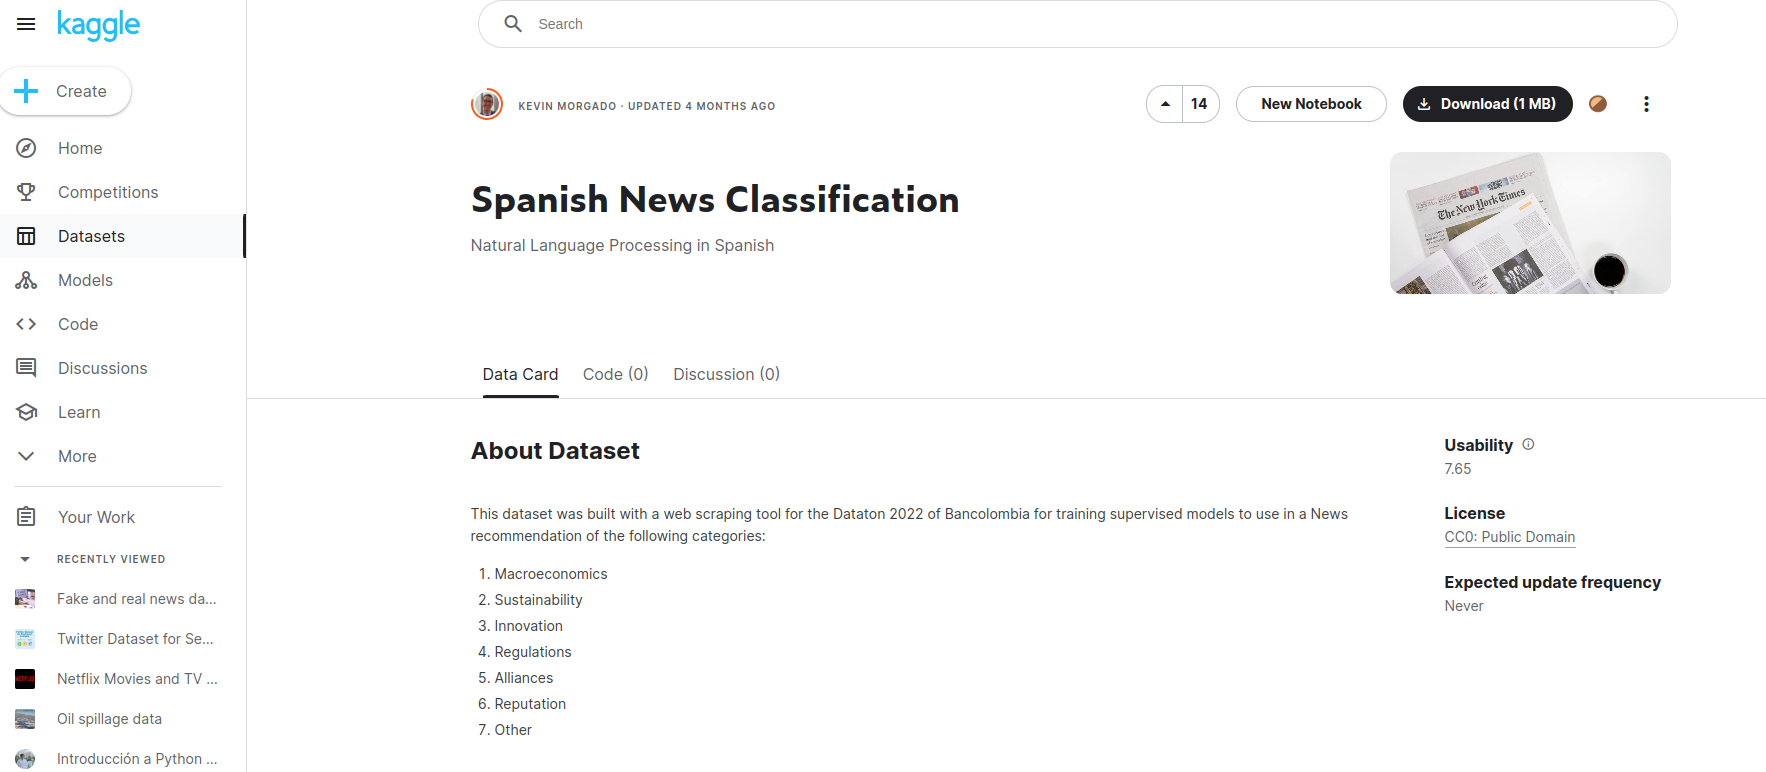

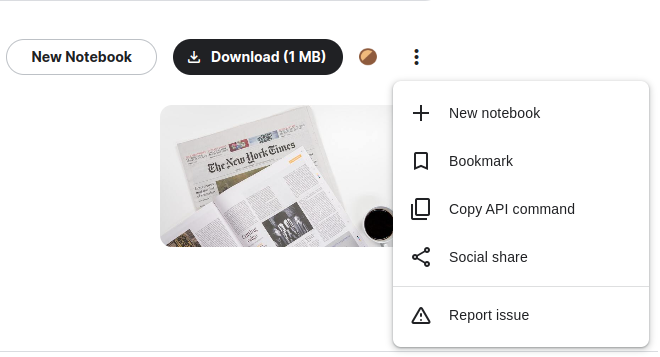

***Presionar el menú de hamburguesa o los 3 puntos y seleccionar `copy API command`***

# Preparamos el entorno de los Ejercicios

In [82]:
!pip install kaggle tabulate

In [83]:
import os
import pandas as pd
from google.colab import userdata, drive, files
import re
from tabulate import tabulate

In [84]:

#1. Montar Drive
drive.mount("/content/drive")

# 2. Extraemos las credenciales de forma segura desde los Secrets de Colab
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
#3. Direcorios y datasets
dir_dataset: str = '/content/drive/MyDrive/kaggle/datasets'
datasets: list[dict] = [
    {
        "dir": "twitter-dataset-for-sentiment-analysis",
        "dataset": "dunyajasim/twitter-dataset-for-sentiment-analysis"
    },
    {
        "dir": "spanish-news-classification",
        "dataset": "kevinmorgado/spanish-news-classification"
    },
    {
        "dir": "criticas-peliculas-filmaffinity-en-espaniol",
        "dataset": "ricardomoya/criticas-peliculas-filmaffinity-en-espaniol"
    }
]

# 3. Creamos los direcorios para cada dataset
for dataset in datasets:
    dir = dataset["dir"]
    os.makedirs(f"{dir_dataset}/{dir}", exist_ok=True)

# 4. Descargamos los datasets
for dataset in datasets:
    dataset_name = dataset["dataset"]
    print(f"Descargando el dataset {dataset_name}...")
    dataset_path = os.path.join(dir_dataset, dataset["dir"])
    ! kaggle datasets download -d {dataset_name} -p {dataset_path} --unzip


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descargando el dataset dunyajasim/twitter-dataset-for-sentiment-analysis...
Dataset URL: https://www.kaggle.com/datasets/dunyajasim/twitter-dataset-for-sentiment-analysis
License(s): GNU Lesser General Public License 3.0
100% 201M/201M [00:02<00:00, 74.9MB/s]

Descargando el dataset kevinmorgado/spanish-news-classification...
Dataset URL: https://www.kaggle.com/datasets/kevinmorgado/spanish-news-classification
License(s): CC0-1.0
100% 1.38M/1.38M [00:00<00:00, 48.3MB/s]

Descargando el dataset ricardomoya/criticas-peliculas-filmaffinity-en-espaniol...
Dataset URL: https://www.kaggle.com/datasets/ricardomoya/criticas-peliculas-filmaffinity-en-espaniol
License(s): CC0-1.0
100% 4.11M/4.11M [00:00<00:00, 61.4MB/s]



# Ejercicio 01

Descargar el dataset `kevinmorgado/spanish-news-classificatio` desde kaggle, levantarlo con pandas y mostrar:
- Mostrar la cantidad de filas
- Mostrar la cantidad de columnas
- Mostrar la cantidad de celdas que posee el dataset
- Mostrar el nombre de las columnas
- Las primeras 10 filas
- Las últimas 15 filas

In [103]:

dataset_info = next((item for item in datasets if item["dataset"] == "kevinmorgado/spanish-news-classification"),None)

spanish_news_classificatio_path = os.path.join(dir_dataset, dataset_info['dir'], "df_total.csv")
df_spanish_news_classificatio = pd.read_csv(spanish_news_classificatio_path)

print(f"Cantidad de filas: {df_spanish_news_classificatio.shape[0]}")
print(f"Cantidad de columnas: {df_spanish_news_classificatio.shape[1]}")
print(f"Cantidad de celdas: {df_spanish_news_classificatio.size}")
print(f"Nombre de las columnas: {df_spanish_news_classificatio.columns.tolist()}")
print("\nPrimeras 10 filas:")
display(df_spanish_news_classificatio.head(10))
print("\nÚltimas 15 filas:")
display(df_spanish_news_classificatio.tail(15))

Cantidad de filas: 1217
Cantidad de columnas: 3
Cantidad de celdas: 3651
Nombre de las columnas: ['url', 'news', 'Type']

Primeras 10 filas:


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra
5,https://www.larepublica.co/redirect/post/3225281,El emprendimiento del sector inmobiliario Rent...,Alianzas
6,https://www.bbva.com/es/mx/mexico-y-el-desafio...,El país tiene pendiente generar más y mejores ...,Macroeconomia
7,https://www.bbva.com/es/podcast-agile-en-la-un...,En el 'podcast' tenemos el placer de entrevist...,Innovacion
8,https://www.bbva.com/es/la-ingenieria-social-e...,"El factor humano, normalmente identificado com...",Innovacion
9,https://www.bbva.com/es/que-hace-un-developer-...,Los perfiles que se demandan en un banco han e...,Innovacion



Últimas 15 filas:


,url,news,Type
1202,https://www.larepublica.co/redirect/post/3227980,El Departamento Administrativo Nacional de Est...,Macroeconomia
1203,https://www.larepublica.co/redirect/post/3324077,En 2021 Bbva en Colombia financió iniciativas ...,Otra
1204,https://www.larepublica.co/redirect/post/3393210,El Indicador adelantado del Índice de Precios ...,Macroeconomia
1205,https://www.bbva.com/es/pe/bbva-data-challenge...,BBVA ha organizado la cuarta edición del 'BBVA...,Innovacion
1206,https://www.larepublica.co/redirect/post/3402736,Las acciones estadounidenses se desplomaron de...,Macroeconomia
1207,https://www.larepublica.co/redirect/post/3036873,La política monetaria la dirige el Banco Repúb...,Regulaciones
1208,https://www.larepublica.co/redirect/post/3311883,Sorprendió el silencio de los candidatos presi...,Regulaciones
1209,https://www.larepublica.co/redirect/post/3401891,La Asociación de Transporte Aéreo Internaciona...,Alianzas
1210,https://www.larepublica.co/redirect/post/3292433,La XVI Cumbre de la Alianza del Pacífico se ll...,Alianzas
1211,https://www.larepublica.co/redirect/post/3312451,La inflación en España volvió a dispararse en ...,Macroeconomia


# Ejercicio 02

Descargar el dataset `criticas-peliculas-filmaffinity-en-espaniol` desde kaggle, levantarlo con pandas y mostrar:
- Mostrar la cantidad de filas
- Mostrar la cantidad de columnas
- Mostrar la cantidad de celdas que posee el dataset
- Mostrar el nombre de las columnas
- Las primeras 10 filas
- Las últimas 15 filas

`Este dataset debería tener un error en los separadores cuando se intenta levantar, encontrar la forma de levantarlo. Describir los pasos para arreglarlo.`


In [86]:
dataset_info_2 = next((item for item in datasets if item['dataset'] == 'ricardomoya/criticas-peliculas-filmaffinity-en-espaniol'), None)
film_affinity_path = os.path.join(dir_dataset, dataset_info_2['dir'], 'reviews_filmaffinity.csv')

# El archivo usa '||' como separador
# Lo abrimos y reemplazamos los '||' por '|'
with open(film_affinity_path, 'r', encoding='utf-8') as file_r:
    lines = file_r.read()
# Por las dudas reempla tambien los pipe indi
lines = re.sub(r"\s\|\s", "-",lines)
lines = re.sub(r"\|\|", "|",lines)
# Guardamos el archivo con la limpieza realizada
with open(film_affinity_path, 'w', encoding='utf-8') as file_w:
    file_w.write(lines)

df_film_affinity = pd.read_csv(film_affinity_path, delimiter="|")
print(f'Cantidad de filas: {df_film_affinity.shape[0]}')
print(f'Cantidad de columnas: {df_film_affinity.shape[1]}')
print(f'Cantidad de celdas: {df_film_affinity.size}')
print(f'Nombre de las columnas: {df_film_affinity.columns.tolist()}')
print('\nPrimeras 10 filas:')
display(df_film_affinity.head(10))
print('\nÚltimas 15 filas:')
display(df_film_affinity.tail(15))


Cantidad de filas: 8601
Cantidad de columnas: 6
Cantidad de celdas: 51606
Nombre de las columnas: ['film_name', 'gender', 'film_avg_rate', 'review_rate', 'review_title', 'review_text']

Primeras 10 filas:


,film_name,gender,film_avg_rate,review_rate,review_title,review_text
0,Ocho apellidos vascos,Comedia,"6,0",3.0,OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO,La mayor virtud de esta película es su existen...
1,Ocho apellidos vascos,Comedia,"6,0",2.0,El perro verde,"No soy un experto cinéfilo, pero pocas veces m..."
2,Ocho apellidos vascos,Comedia,"6,0",2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...
3,Ocho apellidos vascos,Comedia,"6,0",2.0,Aida: The movie,"No sé qué está pasando, si la gente se deja ll..."
4,Ocho apellidos vascos,Comedia,"6,0",2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"Pero cuando amanece,y me quedo solo,siento en ..."
5,Ocho apellidos vascos,Comedia,"6,0",8.0,"Pues si para ti es una mierda, ¿para qué te la...",La llegada de Rafa a Euskadi es como ponerse a...
6,Ocho apellidos vascos,Comedia,"6,0",3.0,"¿LA MÁS TAQUILLERA? ASÍ NOS VA, ESTO ES LO QU...",El nivel del cine y lo peor la capacidad intel...
7,Ocho apellidos vascos,Comedia,"6,0",3.0,España como imposibilidad,Es triste ver una película como ésta y escucha...
8,Ocho apellidos vascos,Comedia,"6,0",1.0,"¿Que le pasa al público español? ¡ah si, Telec...",Puedo entender que Torrente I y II y Lo imposi...
9,Ocho apellidos vascos,Comedia,"6,0",1.0,"AHIVALAOSTIA, PISHA","-Ahivalohostia, Txomin, qué montón de gente ri..."



Últimas 15 filas:


,film_name,gender,film_avg_rate,review_rate,review_title,review_text
8586,La isla mínima,Cine negro,"7,2",8.0,Así sí,No me extraña que recibiese todos los premios ...
8587,La isla mínima,Cine negro,"7,2",8.0,La isla mínima,+: Su estructura de ovillo de lana que se va d...
8588,La isla mínima,Cine negro,"7,2",5.0,"Es como ""True detective"" blablabala...",Vamos a ser directos y a quitarnos de en medio...
8589,La isla mínima,Cine negro,"7,2",10.0,Maestría,Qué decir de un director tan acertado como Alb...
8590,La isla mínima,Cine negro,"7,2",6.0,Tu cara me suena,"Según la estaba viendo, pensaba ""esta ya le he..."
8591,La isla mínima,Cine negro,"7,2",10.0,Y COMO ES ESPAÑOLA UN 10,"Buenísimo.., salgo encantado. Digna de ver, de..."
8592,La isla mínima,Cine negro,"7,2",10.0,Obra maestra,Me ha parecido una obra maestra de principio a...
8593,La isla mínima,Cine negro,"7,2",6.0,La isla mínima,"Una pareja de policías, el poli bueno-demócrat..."
8594,La isla mínima,Cine negro,"7,2",10.0,La isla mínima una película máxima.,Lleva un tiempo el cine español sorprendiéndom...
8595,La isla mínima,Cine negro,"7,2",1.0,Una de las peores películas que he visto!,Esto es lo que consideramos bueno?Pagar una en...


# Ejercicio 03

Tomar los datasets del `ejercicio 02` y realizar las siguientes operaciones:
- Calcular el total de críticas por películas (film_name) y graficarlo con barras. (crear el dataset df_03_film_name)
- Calcular el total de críticas por género (gender) y graficarlo con barras. (crear el dataset df_03_gender)

Los dataset solo deben poseer la columna `count`.


<Axes: title={'center': 'Cantidad de criticas por pelicula'}, xlabel='film_name'>

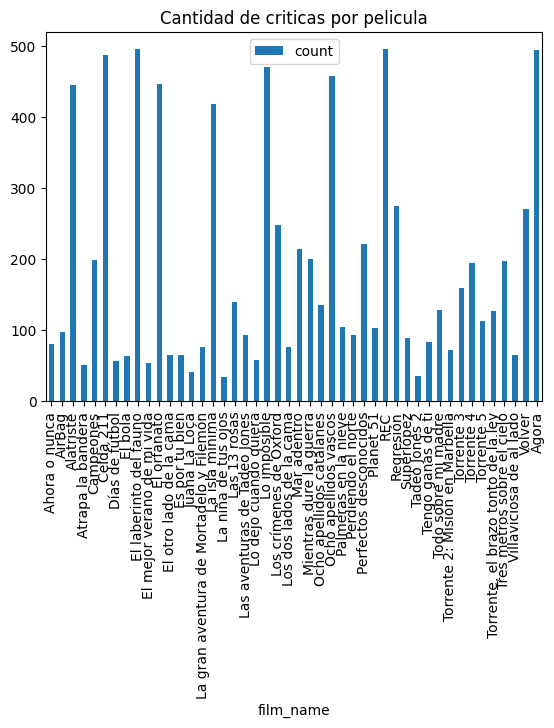

In [87]:
df_03_film_name = df_film_affinity.groupby('film_name').count()
#print(df_03_film_name.head(10))
# renombro la columna porque todos tienen el mismo valor ahora y pisamos el dataframe
df_03_film_name.rename(columns={'gender': 'count'}, inplace=True)
# eliminamos el resto de columnas y dejamos solo count
df_03_film_name.drop(['film_avg_rate', 'review_title', 'review_text', 'review_rate'], axis=1, inplace=True)
df_03_film_name.plot.bar(title="Cantidad de criticas por pelicula")

<Axes: title={'center': 'Cantidad de criticas por genero'}, xlabel='gender'>

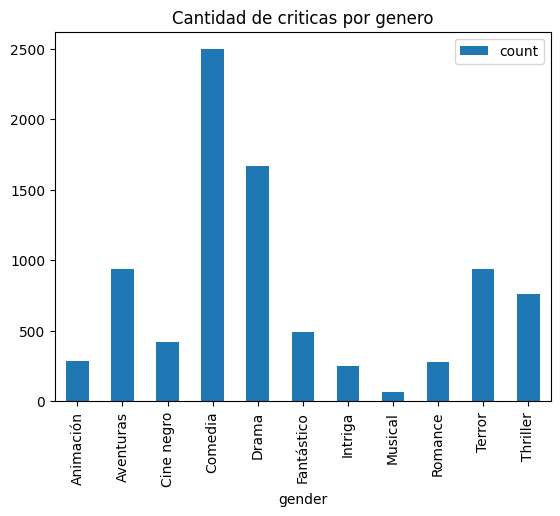

In [88]:
df_03_gender = df_film_affinity.groupby('gender').count()
df_03_gender.rename(columns={'film_name': 'count'}, inplace=True)
df_03_gender.drop(['film_avg_rate', 'review_title', 'review_text', 'review_rate'], axis=1, inplace=True)
df_03_gender.plot.bar(title="Cantidad de criticas por genero")

# Ejercicio 05

Tomar los datasets del `ejercicio 03` (df_03_film_name, df_03_gender) y filtrar por las que tienen más de 400 review y graficarlos.



<Axes: title={'center': 'Peliculas con Criticas Mayore a 400'}, xlabel='film_name'>

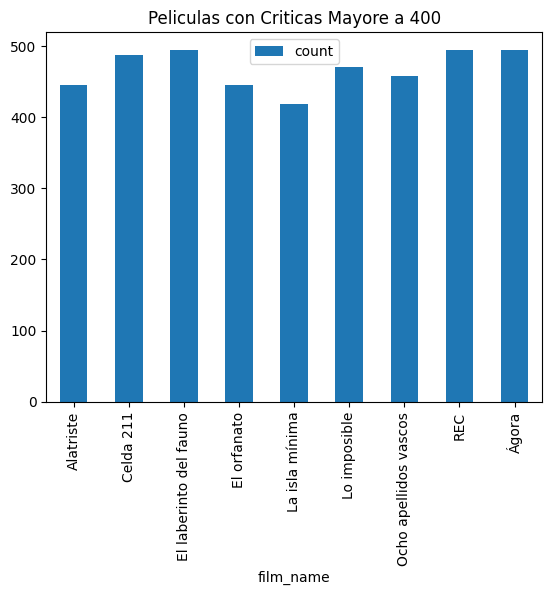

In [89]:
df_03_film_name_reviews = df_03_film_name.query('count > 400')
df_03_film_name_reviews.plot.bar(title="Peliculas con Criticas Mayore a 400")

<Axes: title={'center': 'Generos de Peliculas con Criticas Mayores a 400'}, xlabel='gender'>

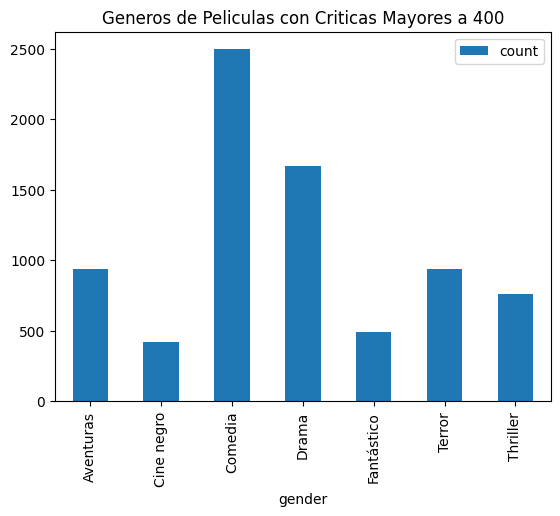

In [90]:
df_03_film_gender_reviews = df_03_gender.query('count > 400')
df_03_film_gender_reviews.plot.bar(title="Generos de Peliculas con Criticas Mayores a 400")

# Ejercicio 06

Tomar el dataset del ejercicio 02 (df_02), pasar los textos (review_text) a un diccionario.

Mostrar una tabla con el film_name y el total de punctuation. _Una película tiene muchas reviews_

```python
reviews = {
  "film_name": [{
    "position": posicion_de_la_review,
    "review_text": "...",
    "punctuation": cantidad_de_puntos_comas_y_puntos_y_comas
    }]
  }
```

In [100]:
# Creamos una copia para trabajar
df_reviews = df_film_affinity[['film_name', 'review_text']].copy()

reviews = {}

for index, row in df_reviews.iterrows():
    name = row['film_name']
    text = str(row['review_text'])
    punctuation_count = len(re.findall(r'[.,;]', text))
    if name not in reviews:
        reviews[name] = []
    reviews[name].append({
        "position": index,
        "review_text": text,
        "punctuation": punctuation_count
    })

table_data = []
for film, data_film in reviews.items():
    total_punctuation = sum(item['punctuation'] for item in data_film)
    table_data.append([film, total_punctuation])

# Mostramos los primeros resultados en una tabla
print(tabulate(table_data, headers=["Film Name", "Total Punctuation"], tablefmt="grid"))

+-----------------------------------------+---------------------+
| Film Name                               |   Total Punctuation |
+=========================================+=====================+
| Ocho apellidos vascos                   |               11630 |
+-----------------------------------------+---------------------+
| Lo imposible                            |               13099 |
+-----------------------------------------+---------------------+
| Ocho apellidos catalanes                |                3476 |
+-----------------------------------------+---------------------+
| El orfanato                             |                9880 |
+-----------------------------------------+---------------------+
| La gran aventura de Mortadelo y Filemón |                1816 |
+-----------------------------------------+---------------------+
| Torrente 2: Misión en Marbella          |                1277 |
+-----------------------------------------+---------------------+
| Ágora   

# Ejercicio 07

Tomar el diccionario del ejercicio 6 y verificar si hay fechas en los textos.

Mostrar el nombre de la película, la review y la posición

In [102]:
# Patrón de regex para fechas comunes
# Grupo 1: DD/MM/AAAA o DD-MM-AAAA
# Grupo 2: AAAA-MM-DD
date_regex = r'(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})|(\d{4}-\d{1,2}-\d{1,2})'
for film, data_film in reviews.items():
    for review in data_film:
        text = review['review_text']
        matches = re.findall(date_regex, text)
        if matches:
            print(f"Película: {film}")
            print(f"Review: {review['review_text']}")
            print(f"Posición: {review['position']}")
            print(f"Fechas encontradas: {matches}")


Película: Ocho apellidos vascos
Review: Ocho apellidos vascos se ha convertido ya en un fenómeno social, siendo una de las películas españolas que más ha arrasado en la taquilla histórica de todos los tiempos. Y quizá vale la pena analizar la película desde un punto de vista sociológico más que artístico, porque no hay grandes hallazgos visuales o argumentales en la película como para destacar algo francamente novedoso o interesante. El film de hecho es una película artesanal, realizada por un director artesano como es Emilio Martínez Lázaro. La película se aprovecha del rocambolesco argumento para explotar una gran serie de situaciones cómicas, sin que haya realmente una conexión dramática entre ellas, sino que Ocho apellidos vascos se convierte en muchos momentos en una larga retahíla de tópicos, encorsetados con más o menos gracia en según qué momentos pero nunca con la función de explicar una historia detrás.Pero como decía, la historia ha cautivado a una gran cantidad de público. 